# Dataset Consistency Analysis

Scans every case in `data/0_test_nifti` (each case = a folder of `class*.nii.gz` files, one
per anatomical label) and analyzes:

1. **Label / filename variability** — which `class*.nii.gz` files exist, and how consistently,
   across cases.
2. **Case-folder naming variability** — the `RMV{year}_{seq}_{modality}_{code}_{code}_{suffix}`
   pattern and how much it actually varies.
3. **Shape / dimension consistency** — per-case volume shape and voxel spacing.
4. **Voxel-count consistency per label** — how much each structure's size varies across cases.
5. **Class overlap analysis** — for every pair of labels that co-occur in a case, how often
   (and how much) their masks actually overlap.

> Run with the `graph-learning/.venv` kernel (has `nibabel`, `numpy`, `matplotlib`).
> No `pandas`/`seaborn` in that environment — everything below is plain numpy + matplotlib.

In [1]:
import re
import itertools
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

DATA_ROOT = Path('data/0_test_nifti')
assert DATA_ROOT.exists(), f'{DATA_ROOT} not found — run from continuity/'

cases = sorted(DATA_ROOT.glob('RMV*'))
print(f'{len(cases)} cases found')

# per-case file listing (name -> path) — done once, reused by every section below
case_files = {c.name: sorted(c.glob('*.nii.gz')) for c in cases}
all_labels = sorted({f.name for files in case_files.values() for f in files})
print(f'{len(all_labels)} unique label filenames across the dataset:')
for name in all_labels:
    print(f'  {name}')

38 cases found
16 unique label filenames across the dataset:
  classAorta.nii.gz
  classArteriaHepatica.nii.gz
  classBloodVessels.nii.gz
  classGallbladder.nii.gz
  classIVC.nii.gz
  classLiver.nii.gz
  classPediculoPortalAnteriorDerecho.nii.gz
  classPediculoPortalDerecho.nii.gz
  classPediculoPortalIzquierdo.nii.gz
  classPediculoPortalPosteriorDerecho.nii.gz
  classTumour.nii.gz
  classVenaHepaticaDerecha.nii.gz
  classVenaHepaticaIzquierda.nii.gz
  classVenaHepaticaMedia.nii.gz
  classVenaPorta.nii.gz
  classViaBiliar.nii.gz


## 1. Label / filename variability

Only 16 distinct filenames appear across all 38 cases — no typos or naming drift at the
string level. The variability is in **which of those 16 are present per case**.

In [2]:
# presence[case][label] = bool
presence = {c: {name: False for name in all_labels} for c in case_files}
for c, files in case_files.items():
    for f in files:
        presence[c][f.name] = True

presence_matrix = np.array([[presence[c][name] for name in all_labels] for c in case_files])
label_freq = presence_matrix.sum(axis=0)

print(f'{"label":45s} {"present":>8s}  {"%":>6s}')
order = np.argsort(-label_freq)
for i in order:
    print(f'{all_labels[i]:45s} {label_freq[i]:8d}  {100*label_freq[i]/len(cases):5.1f}%')

files_per_case = presence_matrix.sum(axis=1)
print(f'\nfiles per case: min={files_per_case.min()} max={files_per_case.max()} '
      f'mean={files_per_case.mean():.1f} (full set = {len(all_labels)})')

label                                          present       %
classAorta.nii.gz                                   38  100.0%
classBloodVessels.nii.gz                            38  100.0%
classGallbladder.nii.gz                             38  100.0%
classIVC.nii.gz                                     38  100.0%
classLiver.nii.gz                                   38  100.0%
classVenaPorta.nii.gz                               38  100.0%
classPediculoPortalAnteriorDerecho.nii.gz           28   73.7%
classPediculoPortalIzquierdo.nii.gz                 28   73.7%
classPediculoPortalPosteriorDerecho.nii.gz          28   73.7%
classVenaHepaticaDerecha.nii.gz                     28   73.7%
classVenaHepaticaMedia.nii.gz                       28   73.7%
classVenaHepaticaIzquierda.nii.gz                   27   71.1%
classPediculoPortalDerecho.nii.gz                   23   60.5%
classArteriaHepatica.nii.gz                         18   47.4%
classTumour.nii.gz                                  12 

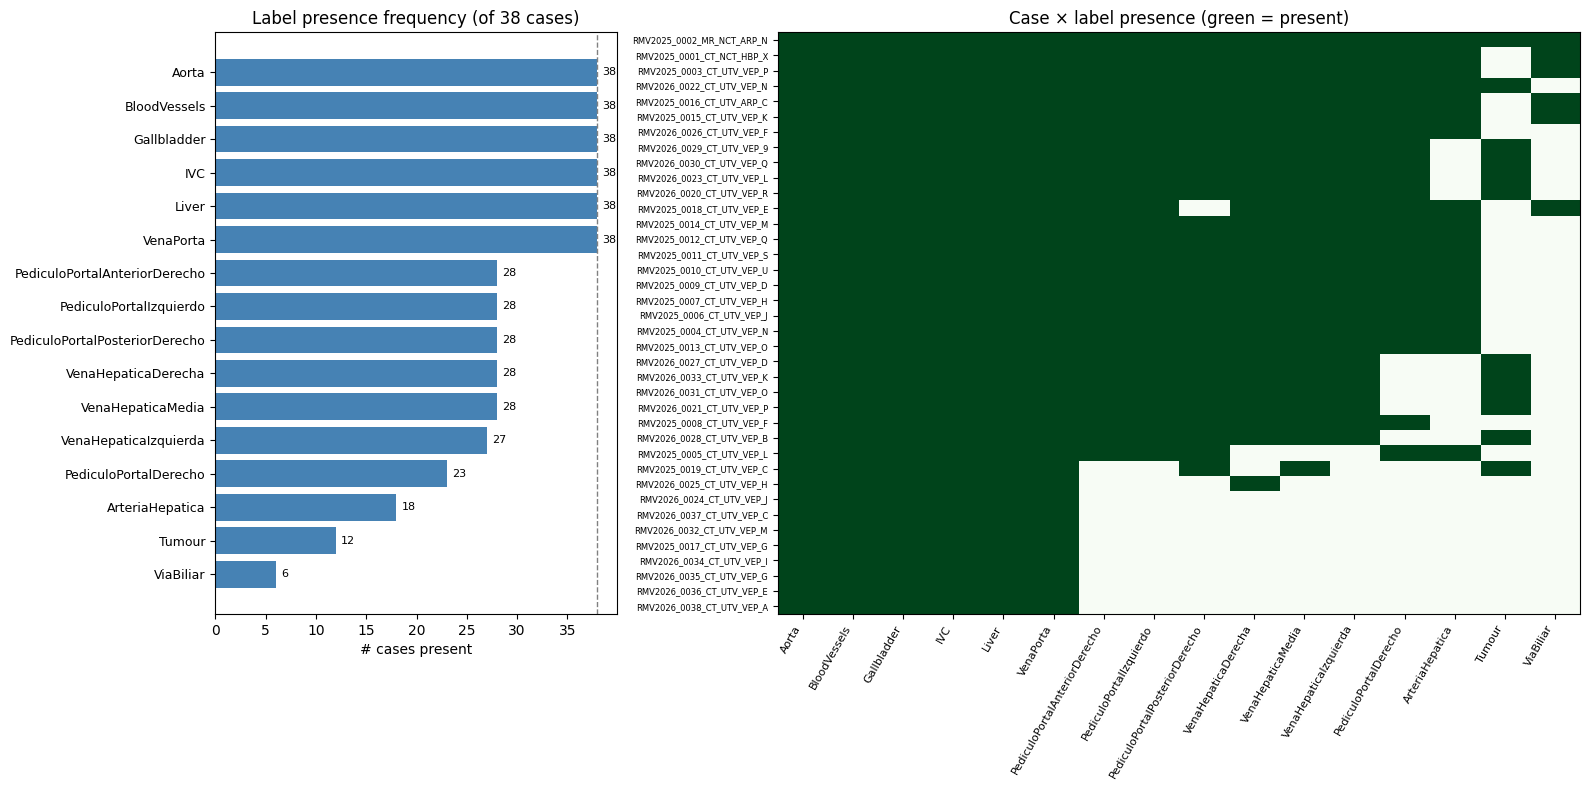

In [3]:
# ---------- charts: label presence bar + case x label heatmap ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [1, 2]})

ax = axes[0]
y = np.arange(len(all_labels))
labels_sorted = [all_labels[i] for i in order]
ax.barh(y, label_freq[order], color='steelblue')
ax.set_yticks(y)
ax.set_yticklabels([n.replace('class', '').replace('.nii.gz', '') for n in labels_sorted], fontsize=9)
ax.invert_yaxis()
ax.axvline(len(cases), color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('# cases present')
ax.set_title(f'Label presence frequency (of {len(cases)} cases)')
for i, v in enumerate(label_freq[order]):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=8)

ax = axes[1]
case_order = np.argsort(-files_per_case)
mat = presence_matrix[case_order][:, order]
ax.imshow(mat, aspect='auto', cmap='Greens', vmin=0, vmax=1)
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels([labels_sorted[i].replace('class', '').replace('.nii.gz', '') for i in range(len(all_labels))],
                    rotation=60, ha='right', fontsize=8)
case_names_sorted = [list(case_files.keys())[i] for i in case_order]
ax.set_yticks(range(len(cases)))
ax.set_yticklabels(case_names_sorted, fontsize=6)
ax.set_title('Case × label presence (green = present)')
plt.tight_layout()
plt.show()

## 1b. Filtering to the hepatic-vein / portal-pedicle subset

For the hepatic vasculature notebooks (`VisualizeHepaticStructures.ipynb`,
`TestMultilabelData.ipynb`) we need cases that have **all 8** of: the 3 `VenaHepatica*`
branches, the 4 `PediculoPortal*` branches, and `IVC`. Filters (non-destructively — nothing on
disk is touched) the `case_files` dict built above down to only those cases.

## 2. Case-folder naming variability

Case folders follow `RMV{year}_{seq}_{modality}_{code2}_{code3}_{suffix}`
(e.g. `RMV2025_0001_CT_NCT_HBP_X`). Parses each component and tabulates how much it varies.

In [4]:
NAME_RE = re.compile(r'^RMV(?P<year>\d{4})_(?P<seq>\d{4})_(?P<modality>[A-Z]+)_(?P<code2>[A-Z]+)_(?P<code3>[A-Z]+)_(?P<suffix>[A-Za-z0-9]+)$')

parsed, unparsed = [], []
for c in case_files:
    m = NAME_RE.match(c)
    if m:
        parsed.append(m.groupdict())
    else:
        unparsed.append(c)

print(f'{len(parsed)}/{len(cases)} case names match the expected pattern')
if unparsed:
    print(f'unparsed ({len(unparsed)}): {unparsed}')

for field in ['year', 'modality', 'code2', 'code3']:
    counts = Counter(p[field] for p in parsed)
    print(f'\n{field}: {dict(sorted(counts.items(), key=lambda x: -x[1]))}')

suffix_counts = Counter(p['suffix'] for p in parsed)
n_dup_suffix = sum(1 for v in suffix_counts.values() if v > 1)
print(f'\nsuffix: {len(suffix_counts)} distinct values over {len(parsed)} cases '
      f'({n_dup_suffix} values reused)')

38/38 case names match the expected pattern

year: {'2025': 19, '2026': 19}

modality: {'CT': 37, 'MR': 1}

code2: {'UTV': 36, 'NCT': 2}

code3: {'VEP': 35, 'ARP': 2, 'HBP': 1}

suffix: 22 distinct values over 38 cases (14 values reused)


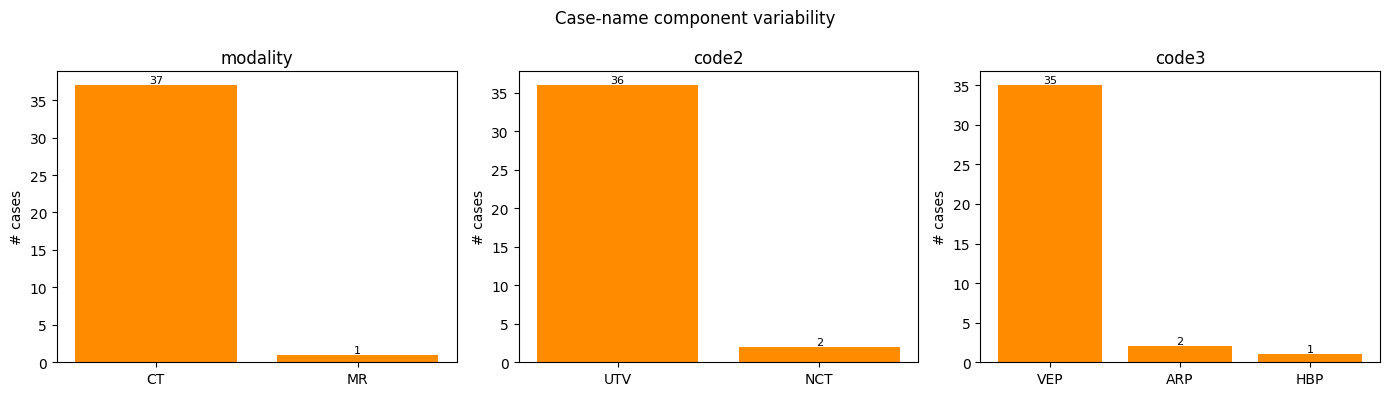

In [5]:
# ---------- chart: case naming components ----------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, field in zip(axes, ['modality', 'code2', 'code3']):
    counts = Counter(p[field] for p in parsed)
    keys = sorted(counts, key=lambda k: -counts[k])
    ax.bar(keys, [counts[k] for k in keys], color='darkorange')
    ax.set_title(field)
    ax.set_ylabel('# cases')
    for i, k in enumerate(keys):
        ax.text(i, counts[k] + 0.3, str(counts[k]), ha='center', fontsize=8)
plt.suptitle('Case-name component variability')
plt.tight_layout()
plt.show()

## 3. Shape / voxel-spacing consistency

Reads one NIfTI header per case (the first `Aorta` file, or any file if absent) and records
the volume shape and voxel spacing (`header.get_zooms()`).

In [6]:
shapes, zooms_all, shape_case = [], [], []
for c, files in case_files.items():
    ref = next((f for f in files if f.name == 'classAorta.nii.gz'), None) or (files[0] if files else None)
    if ref is None:
        continue
    img = nib.load(str(ref))
    shapes.append(img.shape)
    zooms_all.append(tuple(float(z) for z in img.header.get_zooms()[:3]))
    shape_case.append(c)

shapes = np.array(shapes)
zooms_arr = np.array(zooms_all)

print('Shape (voxels)   min / max / mean per axis:')
for ax_i, ax_name in enumerate('XYZ'):
    col = shapes[:, ax_i]
    print(f'  {ax_name}: min={col.min():4d}  max={col.max():4d}  mean={col.mean():6.1f}')

unique_zooms = {tuple(round(v, 3) for v in z) for z in zooms_all}
print(f'\nDistinct voxel-spacing tuples across dataset: {unique_zooms}')
if unique_zooms == {(1.0, 1.0, 1.0)}:
    print('=> every case reports isotropic (1,1,1) spacing in its NIfTI header.')
    print('   (matches reconstruction.py: no affine/spacing transform is applied anywhere '
          'in the pipeline — see lab_diary.md 5.3.)')

Shape (voxels)   min / max / mean per axis:
  X: min= 172  max= 368  mean= 278.6
  Y: min= 144  max= 747  mean= 404.4
  Z: min= 150  max= 577  mean= 237.3

Distinct voxel-spacing tuples across dataset: {(1.0, 1.0, 1.0)}
=> every case reports isotropic (1,1,1) spacing in its NIfTI header.
   (matches reconstruction.py: no affine/spacing transform is applied anywhere in the pipeline — see lab_diary.md 5.3.)


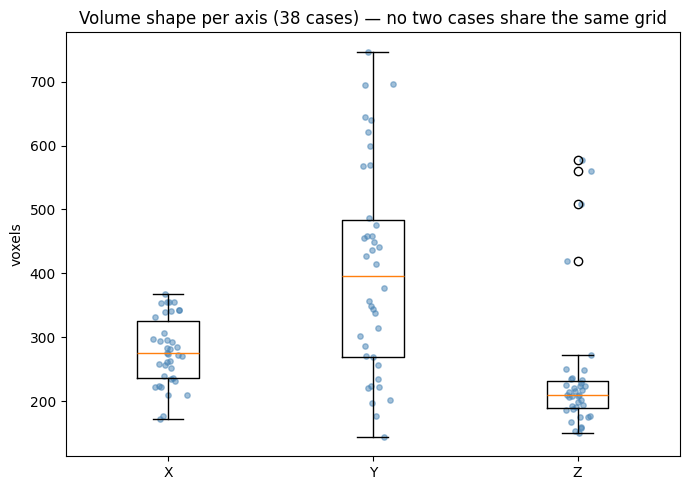

In [7]:
# ---------- chart: shape distribution per axis ----------
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([shapes[:, 0], shapes[:, 1], shapes[:, 2]], labels=['X', 'Y', 'Z'])
for i in range(3):
    jitter = np.random.normal(i + 1, 0.04, size=len(shapes))
    ax.scatter(jitter, shapes[:, i], alpha=0.5, s=15, color='steelblue')
ax.set_ylabel('voxels')
ax.set_title(f'Volume shape per axis ({len(shapes)} cases) — no two cases share the same grid')
plt.tight_layout()
plt.show()

## 4. Per-label voxel-count consistency

For every label, the distribution of `(mask > 0).sum()` across the cases where it's present.

In [8]:
voxel_counts = defaultdict(list)  # label -> [counts across cases where present]
for c, files in case_files.items():
    for f in files:
        d = nib.load(str(f)).get_fdata()
        voxel_counts[f.name].append(int((d > 0).sum()))

print(f'{"label":45s} {"n":>3s} {"min":>8s} {"median":>8s} {"max":>8s} {"cv":>6s}')
for name in labels_sorted:
    v = np.array(voxel_counts[name])
    cv = v.std() / v.mean() if v.mean() > 0 else float('nan')
    print(f'{name:45s} {len(v):3d} {v.min():8d} {int(np.median(v)):8d} {v.max():8d} {cv:6.2f}')

label                                           n      min   median      max     cv
classAorta.nii.gz                              38    19037   171076   419489   0.58
classBloodVessels.nii.gz                       38       23    34008    95488   0.77
classGallbladder.nii.gz                        38      314    24268   142706   0.91
classIVC.nii.gz                                38    17936    87068   129952   0.40
classLiver.nii.gz                              38   119584  1662103  2501522   0.40
classVenaPorta.nii.gz                          38     1947    20892    61185   0.67
classPediculoPortalAnteriorDerecho.nii.gz      28     1021     4161    26279   0.93
classPediculoPortalIzquierdo.nii.gz            28      529     7485    31115   0.75
classPediculoPortalPosteriorDerecho.nii.gz     28      654     5301    27459   0.86
classVenaHepaticaDerecha.nii.gz                28      865    11102    57126   0.89
classVenaHepaticaMedia.nii.gz                  28      710     9028    37434

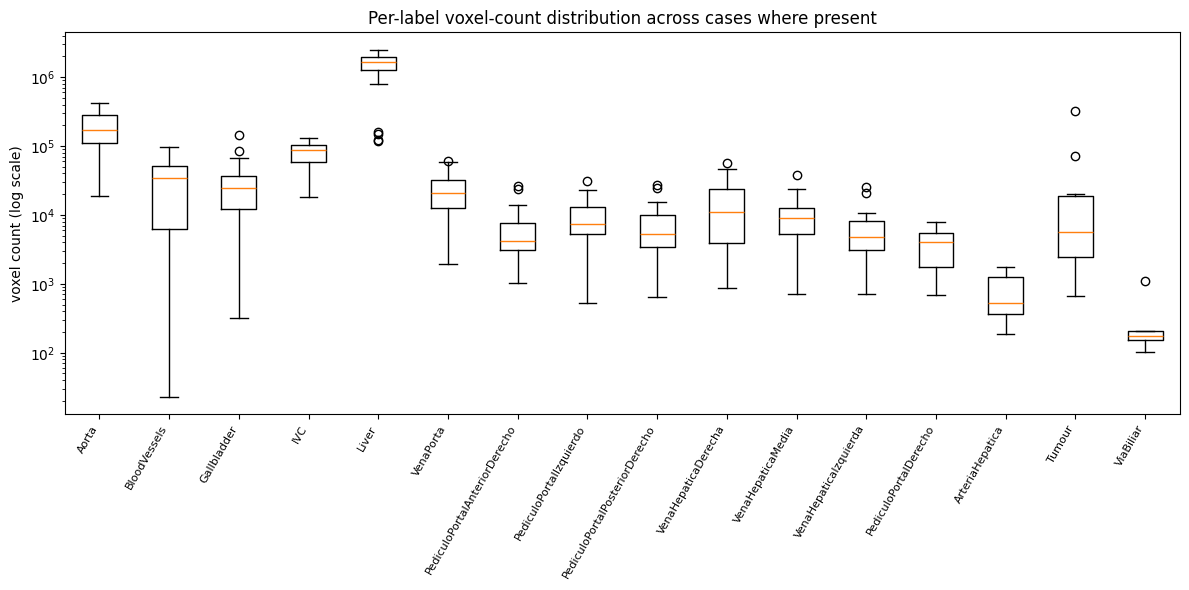

In [9]:
# ---------- chart: voxel count distribution per label (log scale) ----------
fig, ax = plt.subplots(figsize=(12, 6))
data = [voxel_counts[name] for name in labels_sorted]
ax.boxplot(data, labels=[n.replace('class', '').replace('.nii.gz', '') for n in labels_sorted])
ax.set_yscale('log')
ax.set_ylabel('voxel count (log scale)')
ax.set_title('Per-label voxel-count distribution across cases where present')
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Class overlap analysis

For every pair of labels that co-occur in a case, checks whether their binary masks share any
voxels, and if so how many. Aggregated over all 38 cases — this takes ~20s (loads every mask
of every case once).

In [10]:
cooccur_count = defaultdict(int)        # (labelA, labelB) -> # cases where both present
overlap_case_count = defaultdict(int)   # (labelA, labelB) -> # cases where they overlap
overlap_voxels_total = defaultdict(int) # (labelA, labelB) -> summed overlap voxels

for c, files in case_files.items():
    masks = {f.name: (nib.load(str(f)).get_fdata() > 0) for f in files}
    names = sorted(masks.keys())
    for a, b in itertools.combinations(names, 2):
        key = (a, b)
        cooccur_count[key] += 1
        ov = int((masks[a] & masks[b]).sum())
        if ov > 0:
            overlap_case_count[key] += 1
            overlap_voxels_total[key] += ov

print(f'{len(cooccur_count)} label pairs co-occur at least once')
print(f'{len(overlap_case_count)} of those pairs actually overlap in at least one case\n')

print('Top 15 pairs by how often they overlap (when both present):')
ranked = sorted(overlap_case_count.items(), key=lambda x: -x[1])
for (a, b), cnt in ranked[:15]:
    co = cooccur_count[(a, b)]
    avg = overlap_voxels_total[(a, b)] / cnt
    an = a.replace('class', '').replace('.nii.gz', '')
    bn = b.replace('class', '').replace('.nii.gz', '')
    print(f'  {an:24s} <-> {bn:24s}  overlap {cnt:2d}/{co:2d} co-occurring cases  avg {avg:8.0f} vox')

120 label pairs co-occur at least once
73 of those pairs actually overlap in at least one case

Top 15 pairs by how often they overlap (when both present):
  IVC                      <-> Liver                     overlap 38/38 co-occurring cases  avg     7006 vox
  BloodVessels             <-> Liver                     overlap 35/38 co-occurring cases  avg    24865 vox
  Gallbladder              <-> Liver                     overlap 35/38 co-occurring cases  avg     3208 vox
  Liver                    <-> VenaPorta                 overlap 35/38 co-occurring cases  avg     3321 vox
  BloodVessels             <-> IVC                       overlap 30/38 co-occurring cases  avg     4256 vox
  Aorta                    <-> IVC                       overlap 28/38 co-occurring cases  avg      848 vox
  BloodVessels             <-> VenaPorta                 overlap 28/38 co-occurring cases  avg     4631 vox
  Liver                    <-> VenaHepaticaDerecha       overlap 28/28 co-occurring case

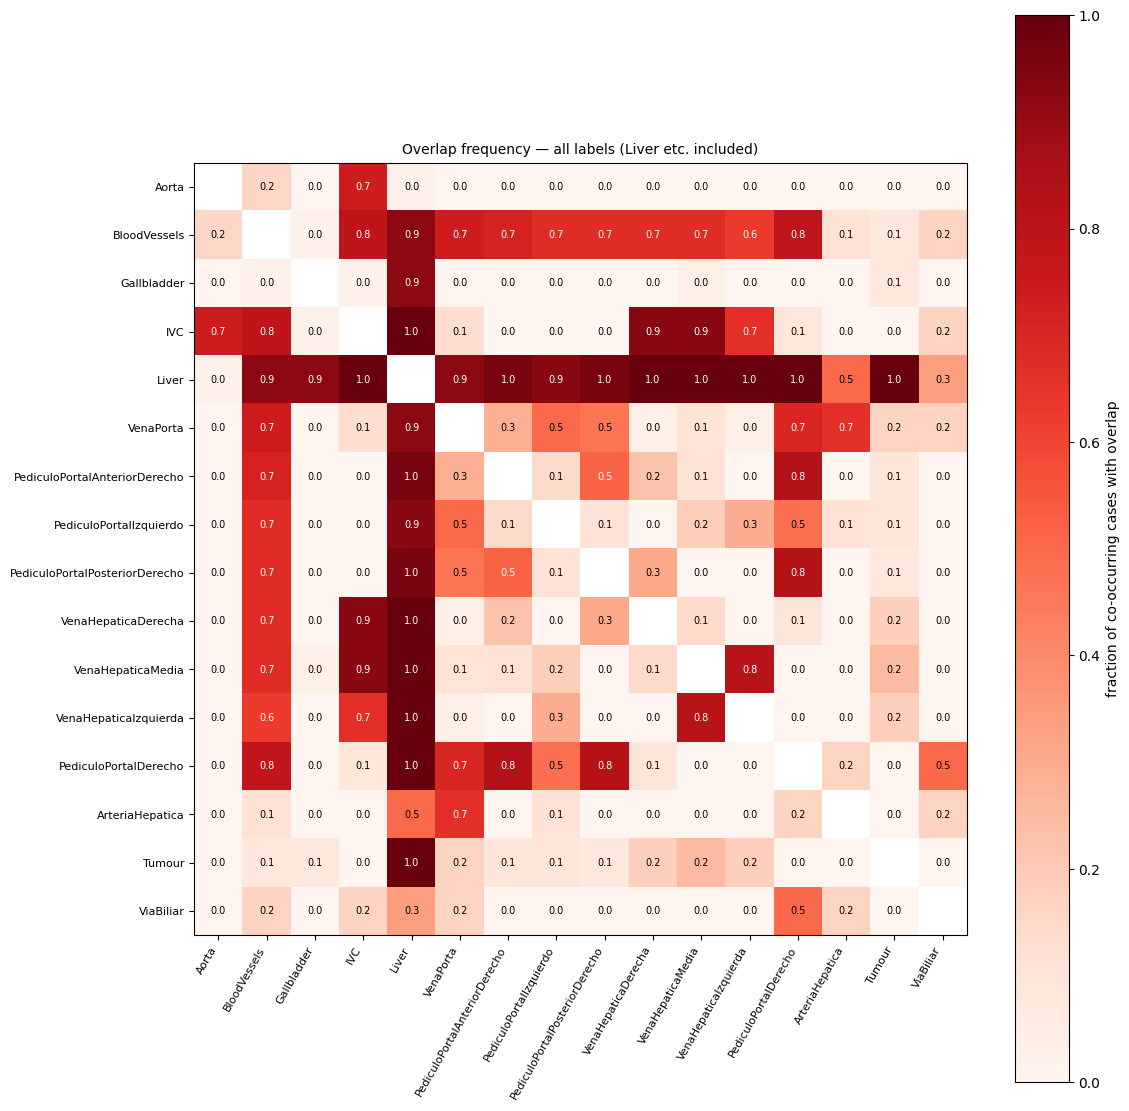

In [11]:
# ---------- heatmap: overlap frequency (fraction of co-occurring cases that overlap) ----------
def overlap_freq_matrix(label_subset):
    n = len(label_subset)
    mat = np.full((n, n), np.nan)
    for i, a in enumerate(label_subset):
        for j, b in enumerate(label_subset):
            if i == j:
                continue
            key = tuple(sorted((a, b)))
            co = cooccur_count.get(key, 0)
            if co == 0:
                continue
            mat[i, j] = overlap_case_count.get(key, 0) / co
    return mat

def plot_overlap_heatmap(label_subset, title):
    mat = overlap_freq_matrix(label_subset)
    short = [n.replace('class', '').replace('.nii.gz', '') for n in label_subset]
    fig, ax = plt.subplots(figsize=(0.55*len(label_subset)+3, 0.55*len(label_subset)+3))
    im = ax.imshow(mat, cmap='Reds', vmin=0, vmax=1)
    ax.set_xticks(range(len(label_subset))); ax.set_xticklabels(short, rotation=60, ha='right', fontsize=8)
    ax.set_yticks(range(len(label_subset))); ax.set_yticklabels(short, fontsize=8)
    for i in range(len(label_subset)):
        for j in range(len(label_subset)):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, f'{mat[i,j]:.1f}', ha='center', va='center', fontsize=7,
                        color='white' if mat[i,j] > 0.5 else 'black')
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, label='fraction of co-occurring cases with overlap')
    plt.tight_layout()
    plt.show()

plot_overlap_heatmap(labels_sorted, 'Overlap frequency — all labels (Liver etc. included)')

12 vascular labels: ['Aorta', 'BloodVessels', 'IVC', 'VenaPorta', 'PediculoPortalAnteriorDerecho', 'PediculoPortalIzquierdo', 'PediculoPortalPosteriorDerecho', 'VenaHepaticaDerecha', 'VenaHepaticaMedia', 'VenaHepaticaIzquierda', 'PediculoPortalDerecho', 'ArteriaHepatica']


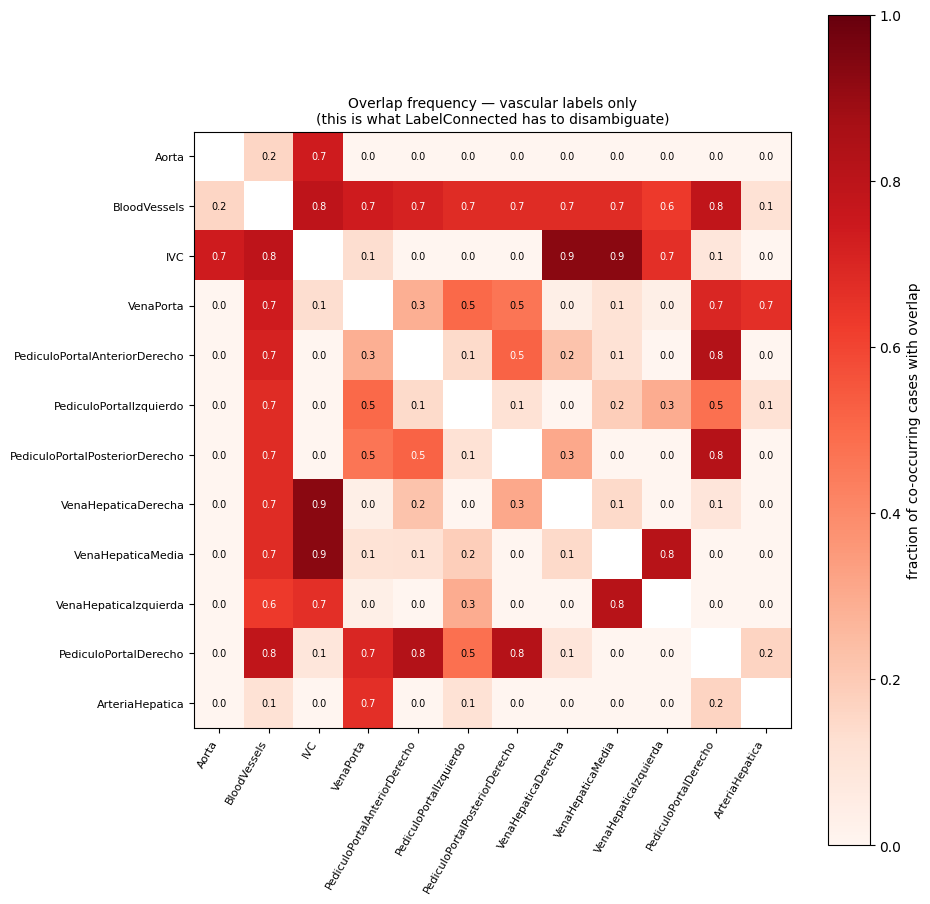

In [12]:
# ---------- vascular-only overlap heatmap (excludes Liver/Gallbladder/Tumour/ViaBiliar) ----------
NON_VASCULAR = {'classLiver.nii.gz', 'classGallbladder.nii.gz', 'classTumour.nii.gz', 'classViaBiliar.nii.gz'}
vascular_labels = [n for n in labels_sorted if n not in NON_VASCULAR]
print(f'{len(vascular_labels)} vascular labels: {[n.replace("class","").replace(".nii.gz","") for n in vascular_labels]}')

plot_overlap_heatmap(vascular_labels, 'Overlap frequency — vascular labels only\n(this is what LabelConnected has to disambiguate)')

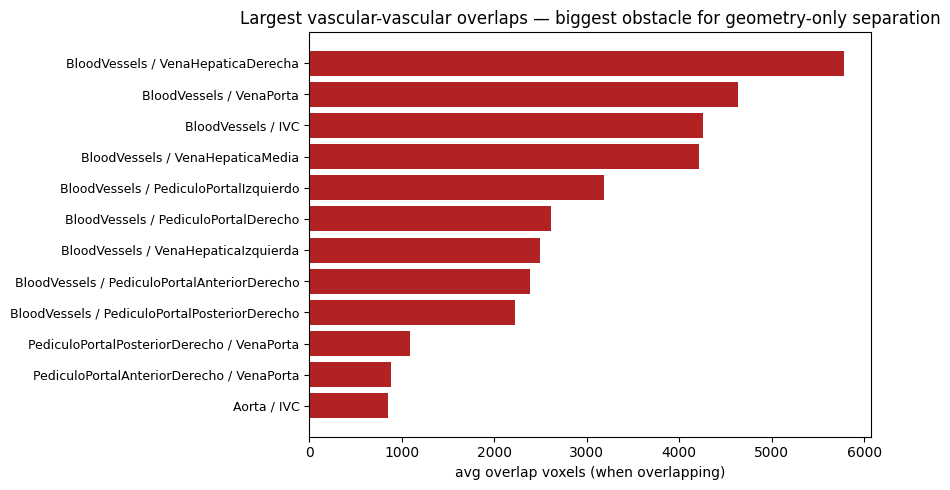

In [13]:
# ---------- bar chart: top vascular-vascular overlap pairs by avg voxel count ----------
vascular_set = set(vascular_labels)
vasc_pairs = [(k, v) for k, v in overlap_case_count.items() if k[0] in vascular_set and k[1] in vascular_set]
vasc_pairs.sort(key=lambda kv: -overlap_voxels_total[kv[0]] / kv[1])

top = vasc_pairs[:12]
labels_txt = [f"{a.replace('class','').replace('.nii.gz','')} / {b.replace('class','').replace('.nii.gz','')}" for (a, b), _ in top]
avg_vox = [overlap_voxels_total[(a, b)] / cnt for (a, b), cnt in top]

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(top))
ax.barh(y, avg_vox, color='firebrick')
ax.set_yticks(y); ax.set_yticklabels(labels_txt, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('avg overlap voxels (when overlapping)')
ax.set_title('Largest vascular-vascular overlaps — biggest obstacle for geometry-only separation')
plt.tight_layout()
plt.show()

## Summary

Fill in after running: which labels are core (present in 100% of cases) vs. optional/rare,
how much the case-folder metadata (modality, protocol codes) actually varies, whether the
shape/spacing story matches the `reconstruction.py` no-affine assumption, which labels have
the widest voxel-count spread, and — most relevant to the LabelConnected question — which
vascular label pairs overlap most consistently and by how much.